This notebook creates diagnostics from the difference computed in step 1.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic_2d, gaussian_kde, linregress
import xarray as xr

In [3]:
def deming_regression(x, y, lambda_ratio=1.0):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    x_mean, y_mean = x.mean(), y.mean()
    Sxx = np.var(x, ddof=1)
    Syy = np.var(y, ddof=1)
    Sxy = np.cov(x, y, ddof=1)[0, 1]

    beta = (
        (Syy - lambda_ratio * Sxx +
         np.sqrt((Syy - lambda_ratio * Sxx)**2 + 4 * lambda_ratio * Sxy**2))
        / (2 * Sxy)
    )

    alpha = y_mean - beta * x_mean
    return alpha, beta

In [4]:
drifter_ds = xr.open_zarr("data/drifters_drogue15m_swath_CalVal_diff.zarr")

In [6]:
drifter_ds["speed"] = (
    drifter_ds["velocity_east"] ** 2 + drifter_ds["velocity_north"] ** 2
) ** 0.5

drifter_ds["speed_gos"] = (
    drifter_ds["ugos"] ** 2 + drifter_ds["vgos"] ** 2
) ** 0.5

drifter_ds["speed_cg_mb"] = (
    drifter_ds["ucg_mb"] ** 2 + drifter_ds["vcg_mb"] ** 2
) ** 0.5

drifter_ds["speed_cg_fp"] = (
    drifter_ds["ucg_fp"] ** 2 + drifter_ds["vcg_fp"] ** 2
) ** 0.5

drifter_ds["speed_cg_gw"] = (
    drifter_ds["ucg_gw"] ** 2 + drifter_ds["vcg_gw"] ** 2
) ** 0.5

In [7]:
nan_mask = (
    np.isnan(drifter_ds.speed_filtered) | 
    np.isnan(drifter_ds.speed_gos) | 
    np.isnan(drifter_ds.speed_cg_mb) | np.isnan(drifter_ds.speed_cg_fp) | np.isnan(drifter_ds.speed_cg_gw)
)

In [8]:
drifter_ds = drifter_ds.where(~nan_mask.compute(), drop=True)

### No restriction on the speed

In [9]:
print(f"Drifters observations: {drifter_ds.points.size}")

Drifters observations: 5257


In [10]:
speed_filtered = drifter_ds.speed_filtered.values
speed_gos = drifter_ds.speed_gos.values
speed_cg_mb = drifter_ds.speed_cg_mb.values
speed_cg_fp = drifter_ds.speed_cg_fp.values
speed_cg_gw = drifter_ds.speed_cg_gw.values

res_lr_gos = linregress(speed_filtered, speed_gos)
res_lr_cg_mb = linregress(speed_filtered, speed_cg_mb)
res_lr_cg_fp = linregress(speed_filtered, speed_cg_fp)
res_lr_cg_gw = linregress(speed_filtered, speed_cg_gw)

In [11]:
print(f"""
    Geos R^2: {(res_lr_gos.rvalue ** 2):.2f}
    CG-MB R^2: {(res_lr_cg_mb.rvalue ** 2):.2f}
    CG-FP R^2: {(res_lr_cg_fp.rvalue ** 2):.2f}
    CG-GW R^2: {(res_lr_cg_gw.rvalue ** 2):.2f}
    """
)


    Geos R^2: 0.46
    CG-MB R^2: 0.44
    CG-FP R^2: 0.47
    CG-GW R^2: 0.46
    


In [13]:
gos_rmsd_filtered = ((drifter_ds["gos_diff"] ** 2).mean() ** 0.5).values
cg_mb_rmsd_filtered = ((drifter_ds["cg_mb_diff"] ** 2).mean() ** 0.5).values
cg_fp_rmsd_filtered = ((drifter_ds["cg_fp_diff"] ** 2).mean() ** 0.5).values
cg_gw_rmsd_filtered = ((drifter_ds["cg_gw_diff"] ** 2).mean() ** 0.5).values

In [14]:
print(f"""
    Geos RMSD: {gos_rmsd_filtered:.2f} m/s
    CG-MB RMSD: {cg_mb_rmsd_filtered:.2f} m/s
    CG-FP RMSD: {cg_fp_rmsd_filtered:.2f} m/s
    CG-GW RMSD: {cg_gw_rmsd_filtered:.2f} m/s
    """
)


    Geos RMSD: 0.19 m/s
    CG-MB RMSD: 0.19 m/s
    CG-FP RMSD: 0.19 m/s
    CG-GW RMSD: 0.19 m/s
    


In [13]:
alpha_l3, beta_l3 = deming_regression(speed_filtered, speed_l3, lambda_ratio=2.0)
alpha_dmd, beta_dmd = deming_regression(speed_filtered, speed_dmd, lambda_ratio=2.0)

In [14]:
xy_l3 = np.vstack([speed_filtered, speed_l3])
z_l3 = gaussian_kde(xy_l3)(xy_l3)

xy_dmd = np.vstack([speed_filtered, speed_dmd])
z_dmd = gaussian_kde(xy_dmd)(xy_dmd)

idx_l3 = z_l3.argsort()
sf_l3, l3_clean, z_l3 = speed_filtered[idx_l3], speed_l3[idx_l3], z_l3[idx_l3]

idx_dmd = z_dmd.argsort()
sf_dmd, dmd_clean, z_dmd = speed_filtered[idx_dmd], speed_dmd[idx_dmd], z_dmd[idx_dmd]

z_min = min(z_l3.min(), z_dmd.min())
z_max = max(z_l3.max(), z_dmd.max())

all_x = np.concatenate([sf_l3, sf_dmd])
all_y = np.concatenate([l3_clean, dmd_clean])
axis_min = min(all_x.min(), all_y.min())
axis_max = max(all_x.max(), all_y.max())

axis_min = 0.0
axis_max = 0.6

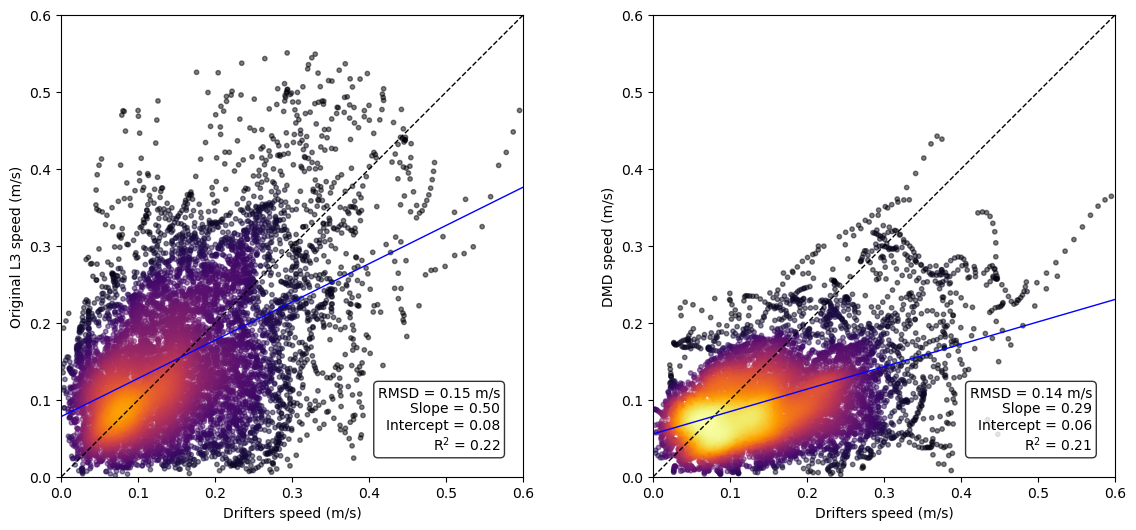

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

_ = axes[0].scatter(sf_l3, l3_clean, c=z_l3, s=10, cmap="inferno", vmin=z_min, vmax=z_max, alpha=0.5)
axes[0].set_xlabel("Drifters speed (m/s)")
axes[0].set_ylabel("Original L3 speed (m/s)")

axes[0].plot([axis_min, axis_max], [axis_min, axis_max], "k--", linewidth=1)
axes[0].plot(
    [axis_min, axis_max], 
    [res_lr_l3.slope * axis_min + res_lr_l3.intercept, res_lr_l3.slope * axis_max + res_lr_l3.intercept], 
    "b-", linewidth=1
)
axes[0].set_xlim(axis_min, axis_max)
axes[0].set_ylim(axis_min, axis_max)
axes[0].set_aspect("equal", adjustable="box")

textstr = (
    f"RMSD = {l3_rmsd_filtered:.2f} m/s\n"
    f"Slope = {res_lr_l3.slope:.2f}\n"
    f"Intercept = {res_lr_l3.intercept:.2f}\n"
    f"R$^2$ = {res_lr_l3.rvalue ** 2:.2f}"
)
axes[0].text(
    0.95, 0.05, textstr, transform=axes[0].transAxes,
    fontsize=10, verticalalignment="bottom", horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

_ = axes[1].scatter(sf_dmd, dmd_clean, c=z_dmd, s=10, cmap="inferno", vmin=z_min, vmax=z_max, alpha=0.5)
axes[1].set_xlabel("Drifters speed (m/s)")
axes[1].set_ylabel("DMD speed (m/s)")

axes[1].plot([axis_min, axis_max], [axis_min, axis_max], "k--", linewidth=1)
axes[1].plot(
    [axis_min, axis_max], 
    [res_lr_dmd.slope * axis_min + res_lr_dmd.intercept, res_lr_dmd.slope * axis_max + res_lr_dmd.intercept], 
    "b-", linewidth=1
)
axes[1].set_xlim(axis_min, axis_max)
axes[1].set_ylim(axis_min, axis_max)
axes[1].set_aspect("equal", adjustable="box")

textstr = (
    f"RMSD = {dmd_rmsd_filtered:.2f} m/s\n"
    f"Slope = {res_lr_dmd.slope:.2f}\n"
    f"Intercept = {res_lr_dmd.intercept:.2f}\n"
    f"R$^2$ = {res_lr_dmd.rvalue ** 2:.2f}"
)
axes[1].text(
    0.95, 0.05, textstr, transform=axes[1].transAxes,
    fontsize=10, verticalalignment="bottom", horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

In [16]:
l3_velocity = drifter_ds.l3_ug + 1j * drifter_ds.l3_vg
l3_mask = np.abs(l3_velocity) > 1e-3
dmd_velocity = drifter_ds.dmd_ug + 1j * drifter_ds.dmd_vg
dmd_mask = np.abs(dmd_velocity) > 1e-3
filtered_velocity = drifter_ds.velocity_east_filtered + 1j * drifter_ds.velocity_north_filtered

mask = (l3_mask & dmd_mask).compute().values

l3_drifter_ratio = filtered_velocity[mask] / l3_velocity[mask]
dmd_drifter_ratio = filtered_velocity[mask] / dmd_velocity[mask]

l3_drifter_ratio_real = l3_drifter_ratio.real.values
l3_drifter_ratio_imag = l3_drifter_ratio.imag.values

dmd_drifter_ratio_real = dmd_drifter_ratio.real.values
dmd_drifter_ratio_imag = dmd_drifter_ratio.imag.values

In [17]:
xy_l3 = np.vstack([l3_drifter_ratio_real, l3_drifter_ratio_imag])
z_l3 = gaussian_kde(xy_l3)(xy_l3)

xy_dmd = np.vstack([dmd_drifter_ratio_real, dmd_drifter_ratio_imag])
z_dmd = gaussian_kde(xy_dmd)(xy_dmd)

idx_l3 = z_l3.argsort()
x_l3, y_l3, z_l3 = l3_drifter_ratio_real[idx_l3], l3_drifter_ratio_imag[idx_l3], z_l3[idx_l3]

idx_dmd = z_dmd.argsort()
x_dmd, y_dmd, z_dmd = dmd_drifter_ratio_real[idx_dmd], dmd_drifter_ratio_imag[idx_dmd], z_dmd[idx_dmd]

z_min = min(z_l3.min(), z_dmd.min())
z_max = max(z_l3.max(), z_dmd.max())

all_x = np.concatenate([x_l3, x_dmd])
all_y = np.concatenate([x_dmd, y_dmd])
axis_min = min(all_x.min(), all_y.min())
axis_max = max(all_x.max(), all_y.max())

axis_min = -3
axis_max = 3

theta = np.linspace(0, 2 * np.pi, 400)

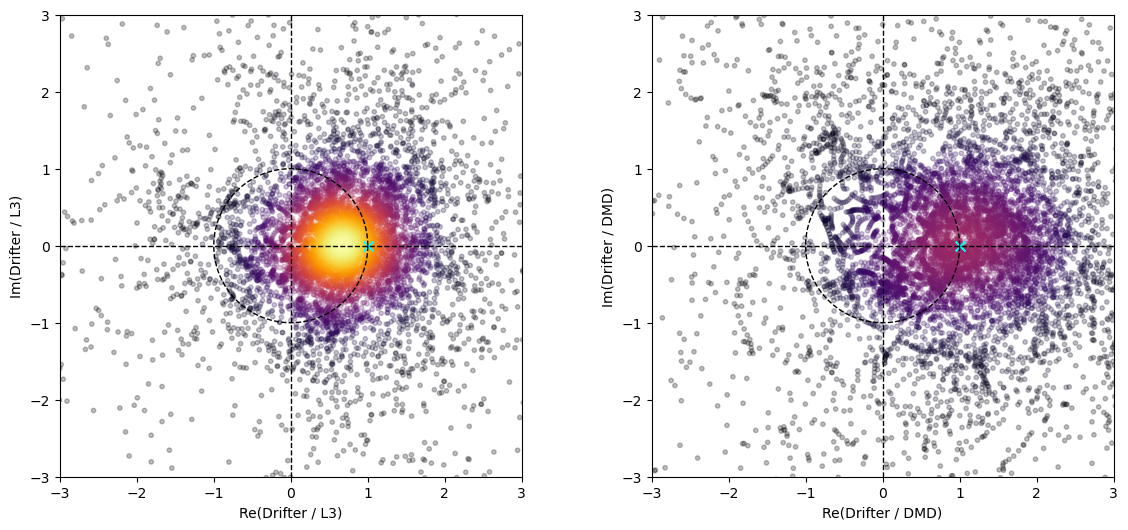

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

_ = axes[0].scatter(x_l3, y_l3, alpha=0.25, s=10, c=z_l3, cmap="inferno", vmin=z_min, vmax=z_max)
axes[0].set_xlabel("Re(Drifter / L3)")
axes[0].set_ylabel("Im(Drifter / L3)")

axes[0].axhline(0, color="k", linestyle="--", linewidth=1)
axes[0].axvline(0, color="k", linestyle="--", linewidth=1)
axes[0].plot(np.cos(theta), np.sin(theta), "k--", linewidth=1)
axes[0].scatter([1], [0], color="cyan", marker="x", s=50, label="Ideal")

axes[0].set_xlim(axis_min, axis_max)
axes[0].set_ylim(axis_min, axis_max)
axes[0].set_aspect("equal", adjustable="box")

_ = axes[1].scatter(x_dmd, y_dmd, alpha=0.25, s=10, c=z_dmd, cmap="inferno", vmin=z_min, vmax=z_max)
axes[1].set_xlabel("Re(Drifter / DMD)")
axes[1].set_ylabel("Im(Drifter / DMD)")

axes[1].axhline(0, color="k", linestyle="--", linewidth=1)
axes[1].axvline(0, color="k", linestyle="--", linewidth=1)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", linewidth=1)
axes[1].scatter([1], [0], color="cyan", marker="x", s=50, label="Ideal")

axes[1].set_xlim(axis_min, axis_max)
axes[1].set_ylim(axis_min, axis_max)
axes[1].set_aspect("equal", adjustable="box")

plt.show()

In [19]:
l3_angle = np.angle(l3_drifter_ratio.values)
dmd_angle = np.angle(dmd_drifter_ratio.values)

bins = np.linspace(-np.pi, np.pi, 72)

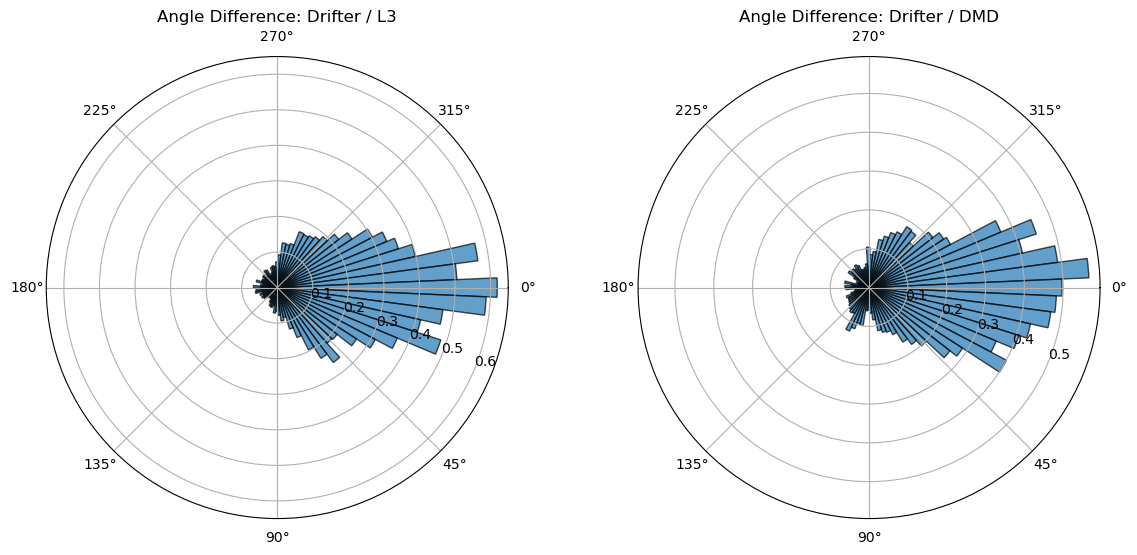

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection="polar"))

axes[0].hist(l3_angle, bins=bins, density=True, alpha=0.7, edgecolor="k")
axes[0].set_title("Angle Difference: Drifter / L3")
axes[0].set_theta_zero_location("E")
axes[0].set_theta_direction(-1)

axes[1].hist(dmd_angle, bins=bins, density=True, alpha=0.7, edgecolor="k")
axes[1].set_title("Angle Difference: Drifter / DMD")
axes[1].set_theta_zero_location("E")
axes[1].set_theta_direction(-1)

plt.show()


In [21]:
df_diff = drifter_ds[["time", "l3_diff_filtered", "dmd_diff_filtered"]].to_dataframe()
df_diff = df_diff.set_index("time").sort_index()

df_rolling = df_diff.rolling("7D").mean()

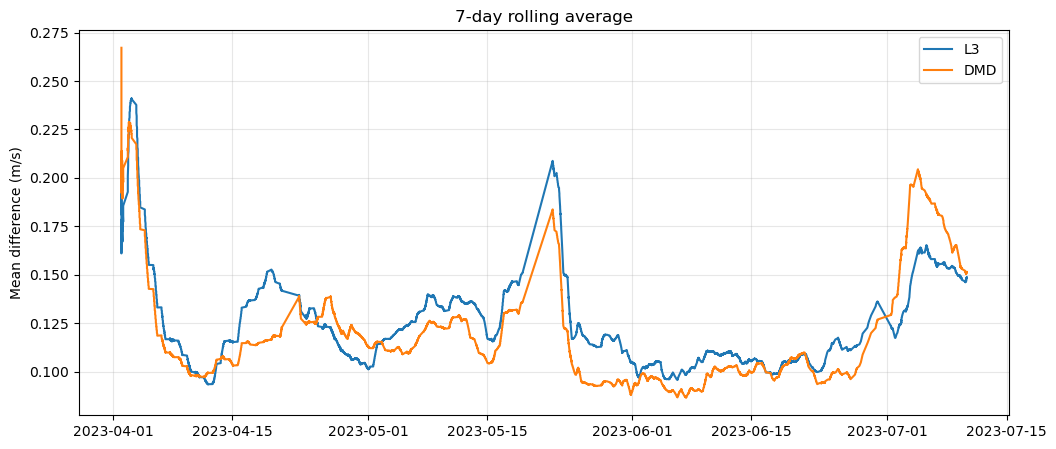

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(df_rolling.index, df_rolling["l3_diff_filtered"], label="L3")
plt.plot(df_rolling.index, df_rolling["dmd_diff_filtered"], label="DMD")

plt.ylabel("Mean difference (m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("7-day rolling average")

plt.show()

In [23]:
lon = drifter_ds.longitude.values
lat = drifter_ds.latitude.values
l3_diff = drifter_ds.l3_diff_filtered.values
dmd_diff = drifter_ds.dmd_diff_filtered.values

bin_size = 0.25
lon_bins = np.arange(np.floor(lon.min()), np.ceil(lon.max()) + bin_size, bin_size)
lat_bins = np.arange(np.floor(lat.min()), np.ceil(lat.max()) + bin_size, bin_size)

stat_l3, lon_edge, lat_edge, _ = binned_statistic_2d(
    lon, lat, l3_diff, statistic="mean", bins=[lon_bins, lat_bins]
)
stat_dmd, _, _, _ = binned_statistic_2d(
    lon, lat, dmd_diff, statistic="mean", bins=[lon_bins, lat_bins]
)

stat_diff = stat_l3 - stat_dmd

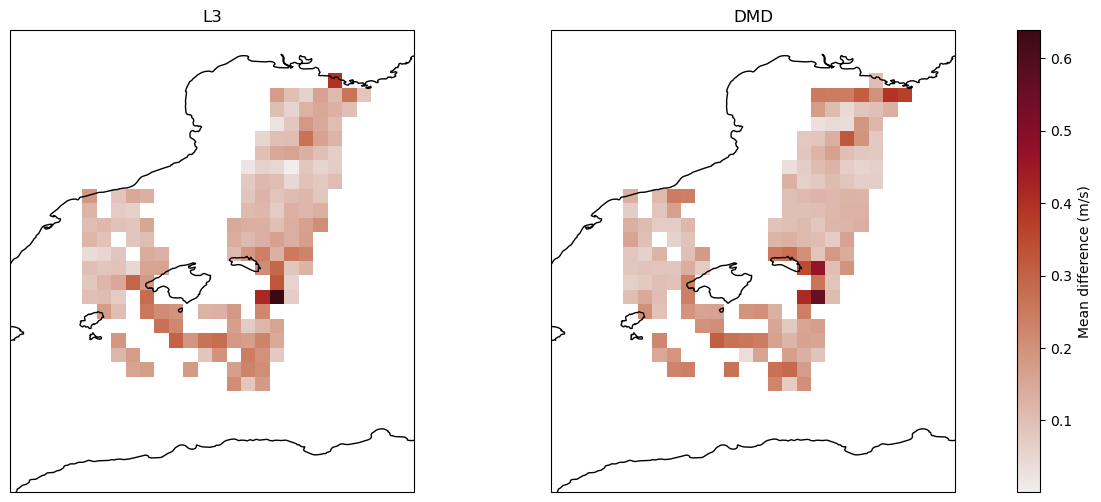

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={"projection": ccrs.PlateCarree()})

vmin = min(np.nanmin(stat_l3), np.nanmin(stat_dmd))
vmax = max(np.nanmax(stat_l3), np.nanmax(stat_dmd))

X, Y = np.meshgrid(lon_edge, lat_edge)

im1 = axes[0].pcolormesh(X, Y, stat_l3.T, cmap=cmo.amp, vmin=vmin, vmax=vmax)
axes[0].coastlines()
axes[0].set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
axes[0].set_title("L3")

im2 = axes[1].pcolormesh(X, Y, stat_dmd.T, cmap=cmo.amp, vmin=vmin, vmax=vmax)
axes[1].coastlines()
axes[1].set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
axes[1].set_title("DMD")

cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label("Mean difference (m/s)")

plt.show()

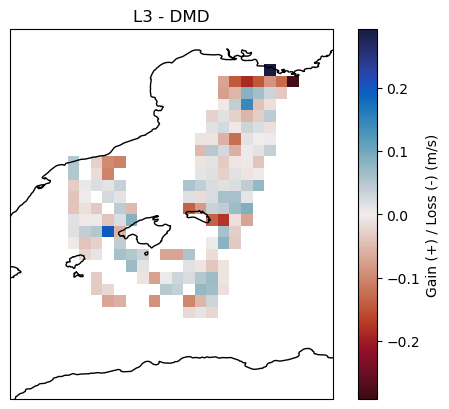

In [25]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

vmax = np.nanmax(np.abs(stat_diff))

X, Y = np.meshgrid(lon_edge, lat_edge)

im1 = ax.pcolormesh(X, Y, stat_diff.T, cmap=cmo.balance_r, vmin=-vmax, vmax=vmax)
ax.coastlines()
ax.set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
ax.set_title("L3 - DMD")

cbar = fig.colorbar(im1, ax=ax)
cbar.set_label("Gain (+) / Loss (-) (m/s)")

plt.show()

### Restricting to small speeds

In [26]:
speed_mask = ((drifter_ds.speed_filtered <= 0.2) & (drifter_ds.speed_l3 <= 0.2) & (drifter_ds.speed_dmd <= 0.2))

In [27]:
drifter_ds = drifter_ds.where(speed_mask.compute(), drop=True)

In [28]:
print(f"Drifters observations: {drifter_ds.points.size}")

Drifters observations: 5652


In [29]:
speed_filtered = drifter_ds.speed_filtered.values
speed_l3 = drifter_ds.speed_l3.values
speed_dmd = drifter_ds.speed_dmd.values

res_lr_l3 = linregress(speed_filtered, speed_l3)
res_lr_dmd = linregress(speed_filtered, speed_dmd)

In [30]:
l3_rmsd_filtered = ((drifter_ds["l3_diff_filtered"] ** 2).mean() ** 0.5).values
dmd_rmsd_filtered = ((drifter_ds["dmd_diff_filtered"] ** 2).mean() ** 0.5).values

In [31]:
print(f"L3 R^2 Drifter: {(res_lr_l3.rvalue ** 2):.2f} ; DMD R^2 Drifter: {(res_lr_dmd.rvalue ** 2):.2f}")

L3 R^2 Drifter: 0.04 ; DMD R^2 Drifter: 0.05


In [32]:
print(f"L3 RMSD Drifter: {l3_rmsd_filtered:.2f} m/s ; DMD RMSD Drifter: {dmd_rmsd_filtered:.2f} m/s")

L3 RMSD Drifter: 0.11 m/s ; DMD RMSD Drifter: 0.10 m/s


In [33]:
xy_l3 = np.vstack([speed_filtered, speed_l3])
z_l3 = gaussian_kde(xy_l3)(xy_l3)

xy_dmd = np.vstack([speed_filtered, speed_dmd])
z_dmd = gaussian_kde(xy_dmd)(xy_dmd)

idx_l3 = z_l3.argsort()
sf_l3, l3_clean, z_l3 = speed_filtered[idx_l3], speed_l3[idx_l3], z_l3[idx_l3]

idx_dmd = z_dmd.argsort()
sf_dmd, dmd_clean, z_dmd = speed_filtered[idx_dmd], speed_dmd[idx_dmd], z_dmd[idx_dmd]

z_min = min(z_l3.min(), z_dmd.min())
z_max = max(z_l3.max(), z_dmd.max())

all_x = np.concatenate([sf_l3, sf_dmd])
all_y = np.concatenate([l3_clean, dmd_clean])
axis_min = min(all_x.min(), all_y.min())
axis_max = max(all_x.max(), all_y.max())

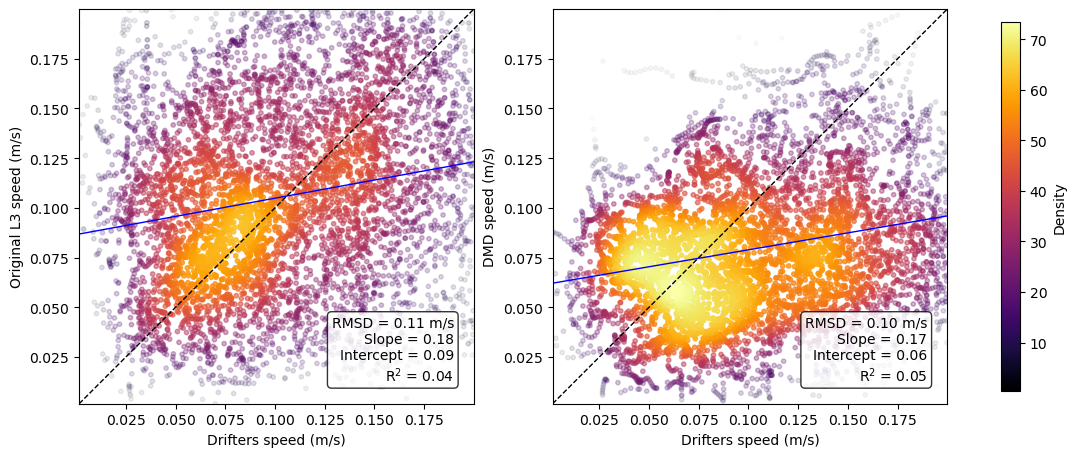

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(
    sf_l3, l3_clean, c=z_l3, s=10, cmap="inferno", vmin=z_min, vmax=z_max, alpha=(z_l3 + 1e-4) / (z_max + 1e-4)
)
axes[0].set_xlabel("Drifters speed (m/s)")
axes[0].set_ylabel("Original L3 speed (m/s)")

axes[0].plot([axis_min, axis_max], [axis_min, axis_max], "k--", linewidth=1)
axes[0].plot(
    [axis_min, axis_max], 
    [res_lr_l3.slope * axis_min + res_lr_l3.intercept, res_lr_l3.slope * axis_max + res_lr_l3.intercept], 
    "b-", linewidth=1
)
axes[0].set_xlim(axis_min, axis_max)
axes[0].set_ylim(axis_min, axis_max)
axes[0].set_aspect("equal", adjustable="box")

textstr = (
    f"RMSD = {l3_rmsd_filtered:.2f} m/s\n"
    f"Slope = {res_lr_l3.slope:.2f}\n"
    f"Intercept = {res_lr_l3.intercept:.2f}\n"
    f"R$^2$ = {res_lr_l3.rvalue ** 2:.2f}"
)
axes[0].text(
    0.95, 0.05, textstr, transform=axes[0].transAxes,
    fontsize=10, verticalalignment="bottom", horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

sc2 = axes[1].scatter(
    sf_dmd, dmd_clean, c=z_dmd, s=10, cmap="inferno", vmin=z_min, vmax=z_max, alpha=(z_dmd + 1e-4) / (z_max + 1e-4)
)
axes[1].set_xlabel("Drifters speed (m/s)")
axes[1].set_ylabel("DMD speed (m/s)")

axes[1].plot([axis_min, axis_max], [axis_min, axis_max], "k--", linewidth=1)
axes[1].plot(
    [axis_min, axis_max], 
    [res_lr_dmd.slope * axis_min + res_lr_dmd.intercept, res_lr_dmd.slope * axis_max + res_lr_dmd.intercept], 
    "b-", linewidth=1
)
axes[1].set_xlim(axis_min, axis_max)
axes[1].set_ylim(axis_min, axis_max)
axes[1].set_aspect("equal", adjustable="box")

textstr = (
    f"RMSD = {dmd_rmsd_filtered:.2f} m/s\n"
    f"Slope = {res_lr_dmd.slope:.2f}\n"
    f"Intercept = {res_lr_dmd.intercept:.2f}\n"
    f"R$^2$ = {res_lr_dmd.rvalue ** 2:.2f}"
)
axes[1].text(
    0.95, 0.05, textstr, transform=axes[1].transAxes,
    fontsize=10, verticalalignment="bottom", horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

cbar = fig.colorbar(sc1, ax=axes, location="right", shrink=0.8)
cbar.set_label("Density")

plt.show()

In [35]:
l3_velocity = drifter_ds.l3_ug + 1j * drifter_ds.l3_vg
l3_mask = np.abs(l3_velocity) > 1e-3
dmd_velocity = drifter_ds.dmd_ug + 1j * drifter_ds.dmd_vg
dmd_mask = np.abs(dmd_velocity) > 1e-3
filtered_velocity = drifter_ds.velocity_east_filtered + 1j * drifter_ds.velocity_north_filtered

mask = (l3_mask & dmd_mask).compute().values

l3_drifter_ratio = filtered_velocity[mask] / l3_velocity[mask]
dmd_drifter_ratio = filtered_velocity[mask] / dmd_velocity[mask]

l3_drifter_ratio_real = l3_drifter_ratio.real.values
l3_drifter_ratio_imag = l3_drifter_ratio.imag.values

dmd_drifter_ratio_real = dmd_drifter_ratio.real.values
dmd_drifter_ratio_imag = dmd_drifter_ratio.imag.values

In [36]:
xy_l3 = np.vstack([l3_drifter_ratio_real, l3_drifter_ratio_imag])
z_l3 = gaussian_kde(xy_l3)(xy_l3)

xy_dmd = np.vstack([dmd_drifter_ratio_real, dmd_drifter_ratio_imag])
z_dmd = gaussian_kde(xy_dmd)(xy_dmd)

idx_l3 = z_l3.argsort()
x_l3, y_l3, z_l3 = l3_drifter_ratio_real[idx_l3], l3_drifter_ratio_imag[idx_l3], z_l3[idx_l3]

idx_dmd = z_dmd.argsort()
x_dmd, y_dmd, z_dmd = dmd_drifter_ratio_real[idx_dmd], dmd_drifter_ratio_imag[idx_dmd], z_dmd[idx_dmd]

z_min = min(z_l3.min(), z_dmd.min())
z_max = max(z_l3.max(), z_dmd.max())

all_x = np.concatenate([x_l3, x_dmd])
all_y = np.concatenate([x_dmd, y_dmd])
axis_min = min(all_x.min(), all_y.min())
axis_max = max(all_x.max(), all_y.max())

axis_min = -3
axis_max = 3

theta = np.linspace(0, 2 * np.pi, 400)

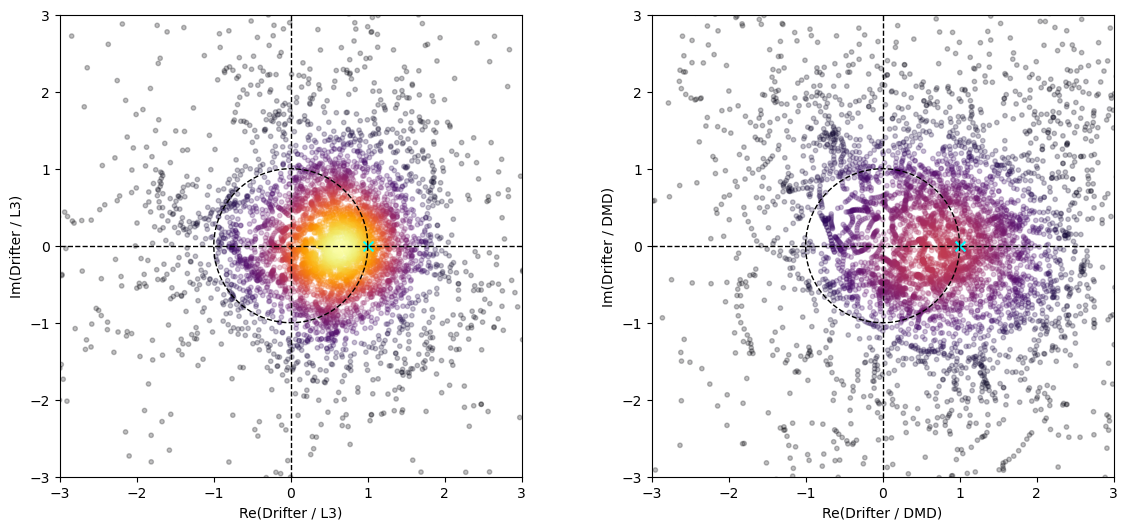

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

_ = axes[0].scatter(x_l3, y_l3, alpha=0.25, s=10, c=z_l3, cmap="inferno", vmin=z_min, vmax=z_max)
axes[0].set_xlabel("Re(Drifter / L3)")
axes[0].set_ylabel("Im(Drifter / L3)")

axes[0].axhline(0, color="k", linestyle="--", linewidth=1)
axes[0].axvline(0, color="k", linestyle="--", linewidth=1)
axes[0].plot(np.cos(theta), np.sin(theta), "k--", linewidth=1)
axes[0].scatter([1], [0], color="cyan", marker="x", s=50, label="Ideal")

axes[0].set_xlim(axis_min, axis_max)
axes[0].set_ylim(axis_min, axis_max)
axes[0].set_aspect("equal", adjustable="box")

_ = axes[1].scatter(x_dmd, y_dmd, alpha=0.25, s=10, c=z_dmd, cmap="inferno", vmin=z_min, vmax=z_max)
axes[1].set_xlabel("Re(Drifter / DMD)")
axes[1].set_ylabel("Im(Drifter / DMD)")

axes[1].axhline(0, color="k", linestyle="--", linewidth=1)
axes[1].axvline(0, color="k", linestyle="--", linewidth=1)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", linewidth=1)
axes[1].scatter([1], [0], color="cyan", marker="x", s=50, label="Ideal")

axes[1].set_xlim(axis_min, axis_max)
axes[1].set_ylim(axis_min, axis_max)
axes[1].set_aspect("equal", adjustable="box")

plt.show()

In [38]:
l3_angle = np.angle(l3_drifter_ratio.values)
dmd_angle = np.angle(dmd_drifter_ratio.values)

bins = np.linspace(-np.pi, np.pi, 72)

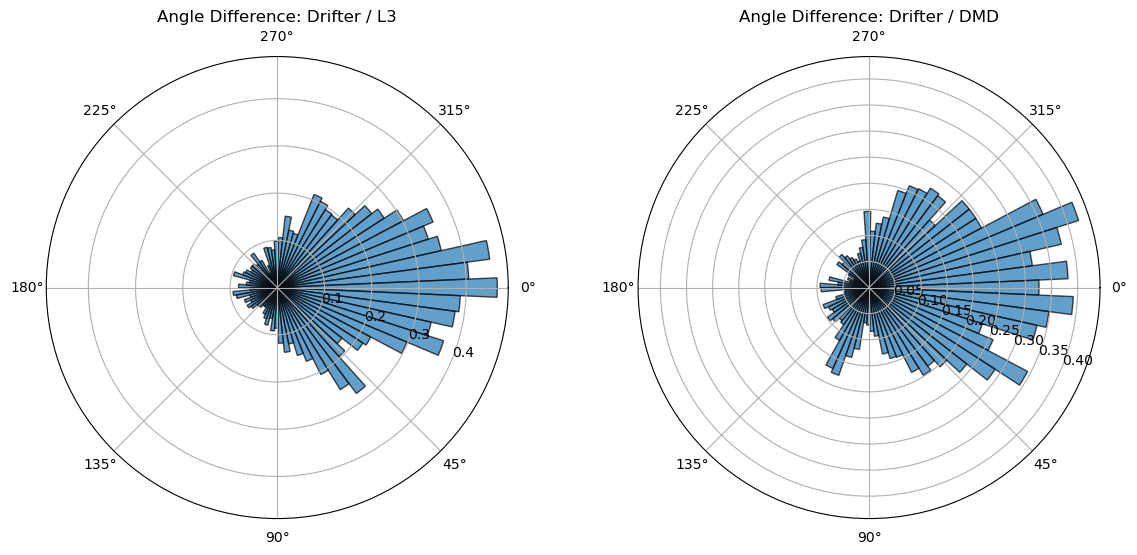

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection="polar"))

axes[0].hist(l3_angle, bins=bins, density=True, alpha=0.7, edgecolor="k")
axes[0].set_title("Angle Difference: Drifter / L3")
axes[0].set_theta_zero_location("E")
axes[0].set_theta_direction(-1)

axes[1].hist(dmd_angle, bins=bins, density=True, alpha=0.7, edgecolor="k")
axes[1].set_title("Angle Difference: Drifter / DMD")
axes[1].set_theta_zero_location("E")
axes[1].set_theta_direction(-1)

plt.show()


In [40]:
df_diff = drifter_ds[["time", "l3_diff_filtered", "dmd_diff_filtered"]].to_dataframe()
df_diff = df_diff.set_index("time").sort_index()

df_rolling = df_diff.rolling("7D").mean()

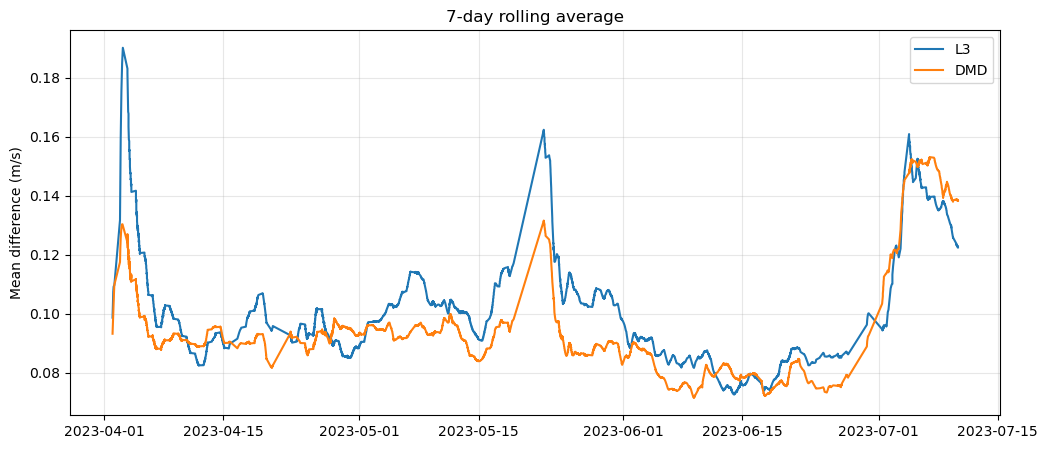

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(df_rolling.index, df_rolling["l3_diff_filtered"], label="L3")
plt.plot(df_rolling.index, df_rolling["dmd_diff_filtered"], label="DMD")

plt.ylabel("Mean difference (m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("7-day rolling average")

plt.show()

In [42]:
lon = drifter_ds.longitude.values
lat = drifter_ds.latitude.values
l3_diff = drifter_ds.l3_diff_filtered.values
dmd_diff = drifter_ds.dmd_diff_filtered.values

bin_size = 0.25
lon_bins = np.arange(np.floor(lon.min()), np.ceil(lon.max()) + bin_size, bin_size)
lat_bins = np.arange(np.floor(lat.min()), np.ceil(lat.max()) + bin_size, bin_size)

stat_l3, lon_edge, lat_edge, _ = binned_statistic_2d(
    lon, lat, l3_diff, statistic="mean", bins=[lon_bins, lat_bins]
)
stat_dmd, _, _, _ = binned_statistic_2d(
    lon, lat, dmd_diff, statistic="mean", bins=[lon_bins, lat_bins]
)

stat_diff = stat_l3 - stat_dmd

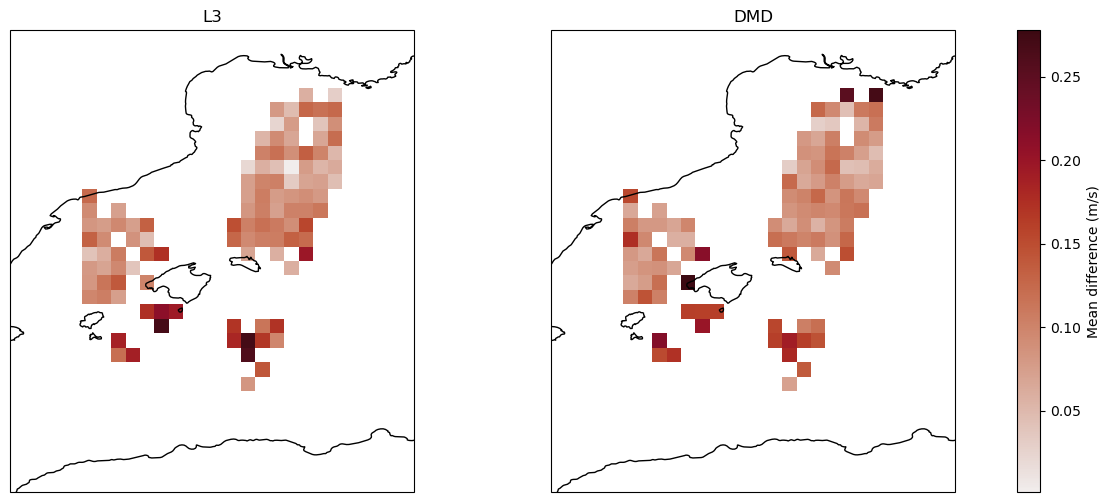

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={"projection": ccrs.PlateCarree()})

vmin = min(np.nanmin(stat_l3), np.nanmin(stat_dmd))
vmax = max(np.nanmax(stat_l3), np.nanmax(stat_dmd))

X, Y = np.meshgrid(lon_edge, lat_edge)

im1 = axes[0].pcolormesh(X, Y, stat_l3.T, cmap=cmo.amp, vmin=vmin, vmax=vmax)
axes[0].coastlines()
axes[0].set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
axes[0].set_title("L3")

im2 = axes[1].pcolormesh(X, Y, stat_dmd.T, cmap=cmo.amp, vmin=vmin, vmax=vmax)
axes[1].coastlines()
axes[1].set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
axes[1].set_title("DMD")

cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label("Mean difference (m/s)")

plt.show()

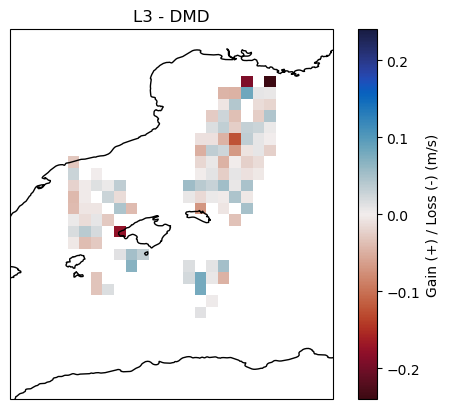

In [44]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

vmax = np.nanmax(np.abs(stat_diff))

X, Y = np.meshgrid(lon_edge, lat_edge)

im1 = ax.pcolormesh(X, Y, stat_diff.T, cmap=cmo.balance_r, vmin=-vmax, vmax=vmax)
ax.coastlines()
ax.set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
ax.set_title("L3 - DMD")

cbar = fig.colorbar(im1, ax=ax)
cbar.set_label("Gain (+) / Loss (-) (m/s)")

plt.show()